# In this script we will explore dlis file

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import logging 
import dlisio 
from dlisio import dlis


In [6]:
filename="/home/ashraf/Downloads/University_of_Utah_MU-ESW1_FMI-HD_7390-7527ft_Run3.dlis"

### Logical files

In [11]:
# With the first logical file stored in f
# All other logical files stored in f_tail

f,*f_tail=dlis.load(filename)

# Check if there is one or more logical files in f_tail
if len(f_tail):logging.warning("There are more logical files in tail")

## Origin

In [13]:
origin, *origin_tail=f.origins

if len(origin_tail): logging.warning("f contains multiple origins")

In [15]:
# Print the description of all origin
for origin in f.origins:
    print(origin.describe())

------
Origin
------
name   : WELL-MU-ESW1
origin : 122
copy   : 0

Logical file ID          : MU-ESW1
File set name and number : MU-ESW1 / 1
File number and type     : 0 / CUSTOMER

Field                   : None
Well (id/name)          :  / MU-ESW1
Produced by (code/name) : 440 / Schlumberger
Produced for            : University of Utah
Created                 : 2019-05-08 11:01:46

Created by              : Techlog, (version: 2013.4.0 (rev: 128578))
Other programs/services : WELL-MU-ESW1


------
Origin
------
name   : DATASET-FMI_HD_7390-7527ft_shift
origin : 123
copy   : 0

Logical file ID          : MU-ESW1
File set name and number : MU-ESW1 / 1
File number and type     : 0 / CUSTOMER

Field                   : None
Well (id/name)          :  / MU-ESW1
Produced by (code/name) : 440 / Schlumberger
Produced for            : University of Utah
Created                 : 2019-05-08 11:01:46

Created by              : Techlog, (version: 2013.4.0 (rev: 128578))
Other programs/services :

# Parameters

In [22]:
# A helper function that extracts specified information from the logical file into a pandas dataframe

def summarize(objs, **kwargs):
    """Create a pd.DataFrame that summarize the content of 'objs', One 
    object pr. row
    
    Parameters
    ----------
    
    objs : list()
        list of metadata objects
        
    **kwargs
        Keyword arguments 
        Use kwargs to tell summarize() which fields (attributes) of the 
        objects you want to include in the DataFrame. The parameter name 
        must match an attribute on the object in 'objs', while the value 
        of the parameters is used as a column name. Any kwargs are excepted, 
        but if the object does not have the requested attribute, 'KeyError' 
        is used as the value.
        
    Returns
    -------
    
    summary : pd.DataFrame
    """

    summary = []
    for attr, label in kwargs.items():
        column=[]
        for obj in objs:
            try:
                value=getattr(obj,attr)
            except AttributeError:
                value ="keyerror"
            
            column.append(value)
        summary.append(column)

    summary=pd.DataFrame(summary).T
    summary.columns=kwargs.values()
    return summary

In [ ]:
# Make a pandas dataframe that contains parameter (constant) details
parameter_table = summarize(f.parameters, name='Name', long_name='Long name', values='Value(s)')

# Add units through the temporary units interface
units_column = []
for i, par in enumerate(f.parameters):
    if i not in parameter_table.index: continue
    try:
        units_column.append(par.attic['VALUES'].units)
    except KeyError:
        units_column.append(None)
parameter_table['Units'] = units_column

# Sort the table alphabetically on parameter name
parameter_table.sort_values('Name')

# Display the first 20 rows of the parameter table
display(parameter_table.head(20))

# Export parameter table to CSV for ease of review
#parameter_table.to_csv('parameter_table.csv', index=False)

,Name,Long name,Value(s),Units
0,TDL,Logger Total Depth,[7546.0],ft
1,PRODUCER-NAME,,[Schlumberger],
2,DFT,Drilling Fluid Type,[WBM],
3,EGL,Elevation of Ground Level,[5536.0],ft
4,DLAB,Date Logger At Bottom,[15-Sep-2017],
5,EPD,Elevation of Permanent Datum (PDAT) above Mean...,[5536.0],ft
6,MRT,Maximum Recorded Temperature,[289.4599914550781],degF
7,MFST,Mud Filtrate Sample Temperature,[74.5],degF
8,RMB,Resistivity of Mud at Bottom Hole Temperature,[0.4027419984340668],ohm.m
9,PRODUCER-CODE,,[440],


## Select a set of key data from the parameter table

In [24]:
key_parameters = ['CN', 'WN', 'FN',                                         # Well ID
                   'NATI', 'CONT', 'FL', 'FL1', 'FL2', 'LONG', 'LATI',      # Well location
                   'DLAB', 'TLAB',                                          # Time and date of well logging
                   'CSIZ', 'BS']                                            # Casing and well parameters


In [25]:

# Create a table out of the parameters in desc_parameters
summary_table = parameter_table.loc[parameter_table['Name'].isin(key_parameters)].copy()

# Sort the table in the same order as desc_parameters
categorical_sorter = pd.Categorical(key_parameters, key_parameters, ordered=True)
summary_table['Name'] = summary_table['Name'].astype(categorical_sorter.dtype)
summary_table.sort_values(by='Name', inplace=True)

display(summary_table)

,Name,Long name,Value(s),Units
37,CN,Company Name,[University of Utah],
27,FN,Field Name,[None],
11,NATI,Nation,[USA],
20,LONG,Longitude,[-112.88703 degrees],
34,LATI,Latitude,[38.500562 degrees],
4,DLAB,Date Logger At Bottom,[15-Sep-2017],
19,TLAB,Time Logger At Bottom,[08:28:00],
31,CSIZ,Current Casing Size,[9.625],in
29,BS,Bit Size,[8.75],in


# Remarks

In [26]:
# Load the remarks from the logical file and print them

remarks = f.find('PARAMETER', '^R[0-9]{1,2}')
remarks = sorted(remarks, key=lambda x: int(x.name[1:]) )

for remark in remarks:
    #if not remark.values: continue    # Uncomment to skip empty remarks
    if remark.name == 'R8': continue   # Hide a remark containing a name; comment out the line to show the remark
    print(f'{remark.name}: {" ".join(remark.values)}')

# If there are no remarks (as can be the case with processed data), then nothing will print.

# Channels

In [27]:
# all channels in one frame are referenced (indexed) against the same value (typically depth)

for frame in f.frames:
    index_channel = next(ch for ch in frame.channels if ch.name == frame.index)
    print(f'Frame {frame.name}:')
    print(f'Description      : {frame.description}')
    print(f'Indexed by       : {frame.index_type}')
    print(f'Interval         : [{frame.index_min}, {frame.index_max}] {index_channel.units}')
    print(f'Direction        : {frame.direction}')
    print(f'Constant spacing : {frame.spacing} {index_channel.units}')
    print(f'Index channel    : {index_channel}')
    print(f'No. of channels  : {len(frame.channels)}')
    print()



Frame FMI_HD_7390-7527FT_SHIFT:
Description      : 
Indexed by       : BOREHOLE-DEPTH
Interval         : [7389.998203217983, 7526.998203217983] ft
Direction        : INCREASING
Constant spacing : 0.008333333333333333 ft
Index channel    : Channel(TDEP)
No. of channels  : 26



In [28]:
channel_table = summarize(
    f.channels, 
    name='Name', 
    long_name='Long name', 
    units='Units',
    dimension='Dimension', 
    frame='Frame')

channel_table.sort_values('Name')

display(channel_table)

,Name,Long name,Units,Dimension,Frame
0,TDEP,,ft,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
1,ARRAY_WBI_IMGCAL,,1/OHMM,[360],Frame(FMI_HD_7390-7527FT_SHIFT)
2,ASSOC_CAL,,in,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
3,AX,,ft/s2,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
4,AY,,ft/s2,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
5,AZ,,ft/s2,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
6,BS,,in,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
7,C1_S,,in,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
8,C2_S,,in,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
9,DEVIM_S,,deg,[1],Frame(FMI_HD_7390-7527FT_SHIFT)


# Tools

In [29]:
# Make a pandas dataframe that contains tool type information
tool_table = summarize(
    f.tools, 
    name='Name', 
    generic_name='Generic name',
    trademark_name='Trademark name', 
    description='Description')

# Sort the table aphapetically by the tool name
tool_table.sort_values('Name')

,Name,Generic name,Trademark name,Description
0,EDTCH,EDTS2G,EDTC-H,Enhanced Digital Telemetry Cartridge - Version H
1,FBST-E,,FBST-E,Full-Bore Scanner Tool E


In [30]:
# Extract metadata associated with a specific tool
selected_tool = f.object(
    'TOOL',         # object type
    'FBST-E'        # object name from table above
    )

selected_tool.describe()

----
Tool
----
name   : FBST-E
origin : 123
copy   : 0

Description    : Full-Bore Scanner Tool E
Trademark name : FBST-E

Channels   : HAZIM_S     FX          FY          FZ          C1_S
             RB_FBST_S   C2_S        DEVIM_S     P1NO_FBST_S AX          AY
             SDEVM       AZ
Parameters : AOFFZ          FOCUS_DIP_RT   EMEXREG        CORINT         FIRMV
             AMWL           CORRELAT_CUT   FOCUS_DIP_AZI  EMXGMOD        AMOR
             GPITF_LOGSPEED MEAS_PNTR      FDBD           AFMO
             C2_SHIFT       MDIP_REJECT    FBST_ACQ_MODE  AMPS           FDBP
             ACAUX_SAFETY   PADT           LARGE_RING     FOFFX
             GAIN_FBST      AMIP           FOFFY          STEP           FOFFZ
             APM            AMRG           FIEQ           EMXCORR        ICMO
             AMPSF1         AMPSF2         AMPSF3         AMPSF4
             LOG_SPEED_RNG  MIN_APP_DIP    GARM_A         FIGA           GARM_B
             GARM_C         FIOF           

In [31]:
selected_tool_param_table = summarize(
    selected_tool.parameters, 
    name='Name', 
    long_name='Long name', 
    values='Value(s)')

selected_tool_param_table.sort_values('Name')

,Name,Long name,Value(s)
19,ACAUX_SAFETY,AC AUX Current Limit Safety,[On]
13,AFMO,Accelerometer Filtering Mode,[HAMMING]
24,AMIP,Adaptive Mode Initial Phase,[0.0]
61,AMMQ,Adaptive Mode Minimum Quality,[3]
9,AMOR,Adaptive Mode Outliers Rejection,[14]
...,...,...,...
62,SEARCH_ANGLE,Angular range to search around focus dip,[60.0]
63,SMALL_RING,Caliper Calibration Small Ring,[8.0]
50,SOFF,Standoff,[-1.0]
26,STEP,Step Length between Correlations,[2.0]


In [32]:
selected_tool_channel_table = summarize(
    selected_tool.channels, 
    name='Name', 
    long_name='Long name', 
    units='Units',
    dimension='Dimension', 
    frame='Frame')

selected_tool_channel_table.sort_values('Name')

,Name,Long name,Units,Dimension,Frame
9,AX,,ft/s2,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
10,AY,,ft/s2,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
12,AZ,,ft/s2,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
4,C1_S,,in,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
6,C2_S,,in,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
7,DEVIM_S,,deg,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
1,FX,,Oe,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
2,FY,,Oe,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
3,FZ,,Oe,[1],Frame(FMI_HD_7390-7527FT_SHIFT)
0,HAZIM_S,,deg,[1],Frame(FMI_HD_7390-7527FT_SHIFT)


# Extract data

In [34]:
# Define the frame

frame = f.object('FRAME', 'FMI_HD_7390-7527FT_SHIFT')

frame.describe()

-----
Frame
-----
name   : FMI_HD_7390-7527FT_SHIFT
origin : 123
copy   : 0

Channel indexing
--
Indexed by       : BOREHOLE-DEPTH
Index units      : ft
Index min        : 7389.998203217983 [ft]
Index max        : 7526.998203217983 [ft]
Direction        : INCREASING
Constant spacing : 0.008333333333333333 [ft]
Index channel    : Channel(TDEP)

Channels
--
TDEP                ARRAY_WBI_IMGCAL    ASSOC_CAL           AX
AY                  AZ                  BS                  C1_S
C2_S                DEVIM_S             FMI_DYN             FMI_STAT
FX                  FY                  FZ                  GR_EDTC_S
HAZIM_S             P1NO_FBST_S         RB_FBST_S           SDEVM
SHIFT_S             SRES_IMGCAL         STICKING_DETECTOR_S TENS
TOOL_ACCELERATION_S TOOL_VELOCITY_S

In [35]:
# Get all curves from the frame
curves = frame.curves()

# Get the desired curve from the curves
FMI_DYN = curves['FMI_DYN']

# Because we are working with a micro-resistivity image log, 
# there are nan values in the gaps between the pads. We need to 
# replace the log nan values (-9999.0) with np.nan to make a nice plot.
FMI_DYN[FMI_DYN == -9999.] = np.nan

# Get the index channel (depth) from the frame
DEPT = curves[frame.index]

# Plot FMI Data 

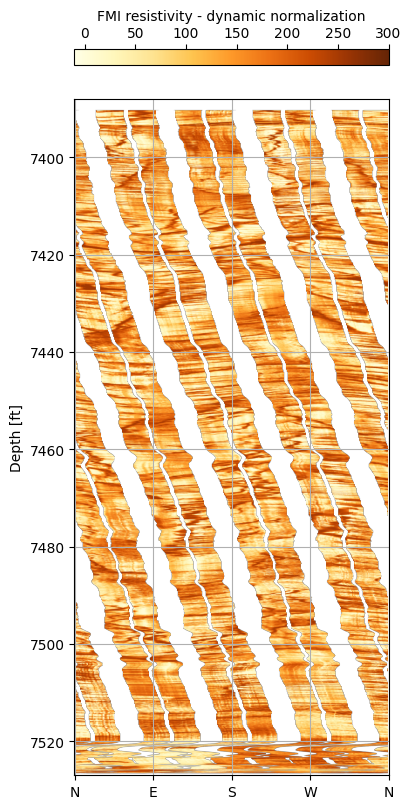

In [ ]:
# A helper function for plotting image logs using matplotlib imshow
def paint_channel(ax, curve, y_axis, x_axis, **kwargs):
    """Plot an image channel into an axes using an index channel for the y-axis
    
    Parameters
    ----------
    
        ax : matplotlib.axes
        
        curve : numpy array
            The curve to be plotted
        
        index : numpy array 
            The depth index as a Channel object (slower) or a numpy array (faster)
        
        **kwargs : dict 
            Keyword arguments to be passed on to ax.imshow()
    """
    # Determine the extent of the image so that the pixel centres correspond with the correct axis values
    dx = np.mean(x_axis[1:] - x_axis[:-1])
    dy = np.mean(y_axis[1:] - y_axis[:-1])
    extent = (x_axis[0] - dx/2, x_axis[-1] + dx/2, y_axis[0] - dy/2, y_axis[-1] + dy/2)
    
    # Determine the correct orientation of the image
    if y_axis[1] < y_axis[0]:   # Frame recorded from the bottom to the top of the well
        origin = 'lower'
    else:                       # Frame recorded from the top to the bottom of the well
        origin = 'upper'
    
    return ax.imshow(curve, aspect='auto', origin=origin, extent=extent, **kwargs)


# Plot the image log
fig, ax = plt.subplots(1,1, figsize=(4,8), sharey=True, constrained_layout=True)

ang = np.arange(360)

im = paint_channel(ax, FMI_DYN, DEPT, ang, cmap='YlOrBr', vmin=-10, vmax=300) 

cbar = fig.colorbar(im, ax=ax, location='top')
cbar.set_label('FMI resistivity - dynamic normalization')

ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N', 'E', 'S', 'W', 'N'])

ax.grid(True)

#ax.set_xlabel('Azimuthal angle from north [°]')
ax.set_ylabel('Depth [ft]')

ax.set_ylim(7388, 7527)
ax.invert_yaxis()

plt.show()


# Rose Plot
It is a circular histogram used to show the frequency distribution of directional data such as angles, azimuths, orientations, strikes, dips, fractures, wind direction, etc.

In [ ]:
# Rose plot diagram

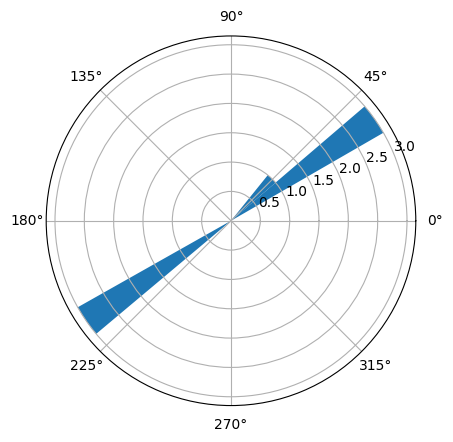

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

angles = np.array([30,35,40,42,210,215,220])
angles = np.deg2rad(angles)

bins = 28
plt.subplot(111, polar=True)
plt.hist(angles, bins=bins)
plt.show()